# TFM – Marketing Fintech Campaign Analysis

<a id="indice"></a>
## Índice

- [Introducción](#introduccion)
- [Imports](#imports)
- [Carga de datos](#carga-datos)
- [Exploración de datos inicial](#exploracion)
- [Visualización de los datos](#visualizacion)
- [Análisis de los datos](#analisis)
- [KPIs](#kpis)
- [Conclusiones](#conclusiones)


<a id="introduccion"></a>
## Introducción 📑

Este Notebook forma parte del **Trabajo Final de Máster (TFM)** enfocado al análisis de datos en el ámbito del marketing financiero.

El objetivo del proyecto es **analizar la información procedente de campañas de marketing telefónicas realizadas por una entidad bancaria**, con el fin de comprender qué factores influyen en la decisión de los clientes de contratar un depósito a plazo fijo.

A partir del análisis del dataset se busca identificar **patrones de comportamiento, variables relevantes y segmentos de clientes** que presenten mayor probabilidad de conversión.

En este documento se desarrollan las primeras fases del proyecto:

1. **Carga y revisión inicial del dataset**  
   - Importación del conjunto de datos y comprobación de su estructura.  
   - Análisis general del número de variables, tipos de datos y consistencia de la información.  
   - Primera inspección del contenido del dataset.

2. **Preparación y exploración inicial de los datos**  
   - Identificación de posibles valores problemáticos (categorías desconocidas, valores atípicos o inconsistencias).  
   - Evaluación de la calidad del dataset.  
   - Creación o transformación de variables que permitan enriquecer el análisis posterior.

3. **Análisis exploratorio de datos (EDA)**  
   - Estudio de variables demográficas como edad, profesión, nivel educativo o estado civil.  
   - Análisis de variables relacionadas con la campaña de marketing, como el tipo de contacto, el número de interacciones o la duración de las llamadas.  
   - Evaluación de la respuesta de los clientes ante la campaña (`y`).

4. **Análisis de relaciones entre variables**  
   - Comparación de diferentes segmentos de clientes según su comportamiento frente a la campaña.  
   - Identificación de patrones y posibles factores asociados a una mayor probabilidad de conversión.

5. **Modelo predictivo de conversión**  
   - Desarrollo de un modelo de predicción cuyo objetivo es estimar la probabilidad de que un cliente acepte la oferta del depósito a plazo fijo (`y = yes`).  
   - Evaluación del rendimiento del modelo y análisis de las variables con mayor capacidad predictiva.

El propósito de este análisis es **comprender mejor los factores que influyen en la efectividad de las campañas de marketing**, así como proporcionar información útil para mejorar la segmentación de clientes y optimizar futuras estrategias comerciales.

[⬆ Volver al índice](#indice)

<a id="imports"></a>
## Imports 📦

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from functions import *

# Expresiones regulares
import re
from fuzzywuzzy import process

c:\Users\migue\anaconda3\envs\TFM\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


[⬆ Volver al índice](#indice)

<a id="carga-datos"></a>
## Carga de datos 📂

In [2]:
df = pd.read_csv('../Data/bank-additional_bank-additional-full.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="exploracion"></a>
## Exploración de datos inicial 🔎

In [3]:
check_df(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 41,188 filas y 21 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



##########################################################################################

Estadísticas descriptivas (categóricas):


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548



##########################################################################################



(       age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 0       56       261         1    999         0           1.1          93.994   
 1       57       149         1    999         0           1.1          93.994   
 2       37       226         1    999         0           1.1          93.994   
 3       40       151         1    999         0           1.1          93.994   
 4       56       307         1    999         0           1.1          93.994   
 ...    ...       ...       ...    ...       ...           ...             ...   
 41183   73       334         1    999         0          -1.1          94.767   
 41184   46       383         1    999         0          -1.1          94.767   
 41185   56       189         2    999         0          -1.1          94.767   
 41186   44       442         1    999         0          -1.1          94.767   
 41187   74       239         3    999         1          -1.1          94.767   
 
        cons.c

In [4]:
identificacion_valores_problem(df)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
age               0.0
campaign          0.0
nr.employed       0.0
euribor3m         0.0
cons.conf.idx     0.0
cons.price.idx    0.0
emp.var.rate      0.0
poutcome          0.0
previous          0.0
pdays             0.0
duration          0.0
job               0.0
day_of_week       0.0
month             0.0
contact           0.0
loan              0.0
housing           0.0
default           0.0
education         0.0
marital           0.0
y                 0.0
dtype: float64
###################################################################################
3.1.2. Número de DUPLICADOS totales: 12
###################################################################################
3.1.3. Columnas numéricas con OUTLIERS
Número de outliers en la columna "age": 469
Número de outliers en la columna "duration": 2963
Número de outliers e

In [5]:
print('la información duplicada que tenemos:')
df[df.duplicated()]

la información duplicada que tenemos:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [6]:
df.drop_duplicates(df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="visualizacion"></a>
## Visualización de los datos 📊

In [7]:
df[['pdays','previous']].value_counts()

pdays  previous
999    0           35563
       1            3696
       2             349
3      1             250
6      1             220
                   ...  
13     3               1
11     4               1
2      5               1
12     4               1
999    6               1
Name: count, Length: 96, dtype: int64

Parece que el valor 999 tambíen está utilizado por personas que ya han sido contactados.

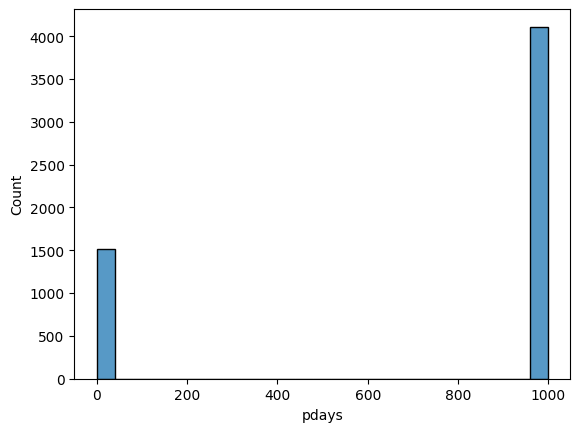

In [8]:
fig = sns.histplot(
    data=df.query('previous > 0'), 
    x="pdays",
    bins= 25
    )

Es el valor más utilizado. Hay que clarificar que significa el 999, si tambíen significa que ha sido mucho tiempo desde el último contacto.

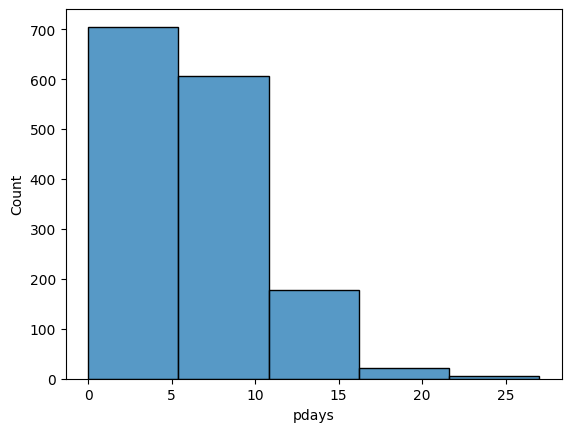

In [9]:
fig = sns.histplot(
    data=df.query('previous > 0 & pdays != 999'), 
    x="pdays",
    bins= 5
    )

Hay gente que han contactado bastante, pero la gran mayoría tienen menos de 10-11 intentos.

In [10]:
df.query('pdays != 999')['pdays'].describe().round(2)

count    1515.00
mean        6.01
std         3.82
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64

El máximo de días de contacto es 27 días, exceptuando los 999.

In [11]:
print(df['age'].value_counts())
print('-'*50)
print(df.age.unique())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64
--------------------------------------------------
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]


Las personas más contactadas tienen una edad de 31 a 35 años.

In [12]:
df['campaign'].value_counts()

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
17       58
16       51
15       51
18       33
20       30
19       26
21       24
22       17
23       16
24       15
27       11
29       10
28        8
26        8
25        8
31        7
30        7
35        5
32        4
33        4
34        3
42        2
40        2
43        2
56        1
39        1
41        1
37        1
Name: count, dtype: int64

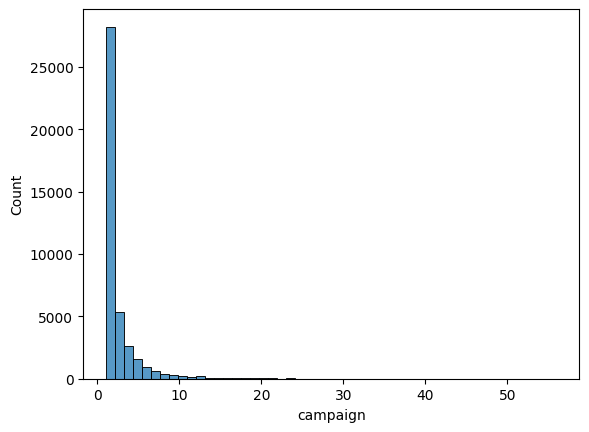

In [13]:
fig = sns.histplot(
    data=df, 
    x="campaign",
    bins= 50
    )

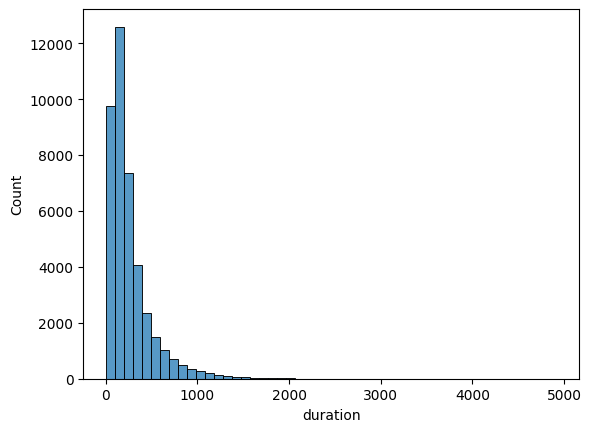

In [14]:
fig = sns.histplot(
    data=df, 
    x="duration",
    bins= 50
    )

-------

#### Valores Categoricos

In [15]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [16]:
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [17]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [18]:
df['housing'].value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [19]:
df['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [20]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

#### Campañas Previas

In [21]:
df['previous'].value_counts()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

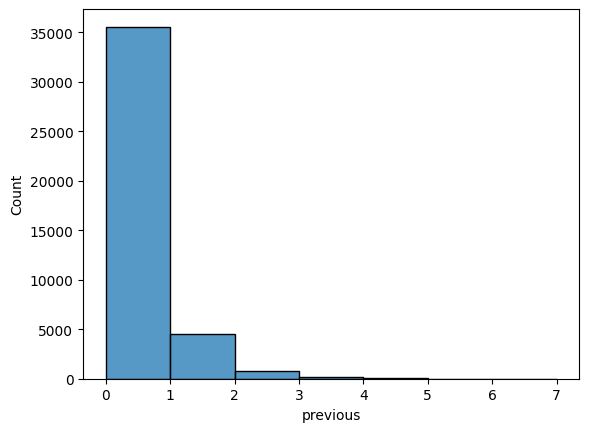

In [22]:
fig = sns.histplot(
    data=df, 
    x="previous",
    bins = 7
        )


In [23]:
df['poutcome'].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

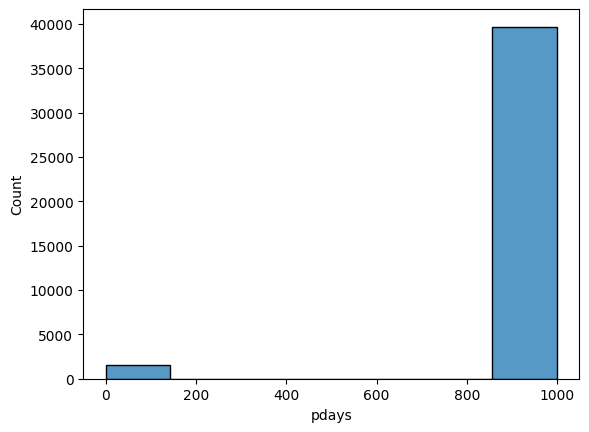

In [24]:
fig = sns.histplot(
    data=df, 
    x="pdays",
    bins = 7
        )


-----
#### Puntos de referencia - Euribor, Empleos, etc.

In [25]:
df[['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].describe().round(2)

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00
mean,0.08,93.58,-40.50,3.62,5167.04
std,1.57,0.58,4.63,1.73,72.25
min,-3.40,92.20,-50.80,0.63,4963.60
25%,-1.80,93.08,-42.70,1.34,5099.10
50%,1.10,93.75,-41.80,4.86,5191.00
75%,1.40,93.99,-36.40,4.96,5228.10
max,1.40,94.77,-26.90,5.04,5228.10


In [26]:
df[['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].agg(['median']).transpose()

,median
emp.var.rate,1.100
cons.price.idx,93.749
cons.conf.idx,-41.800
euribor3m,4.857
nr.employed,5191.000


-----


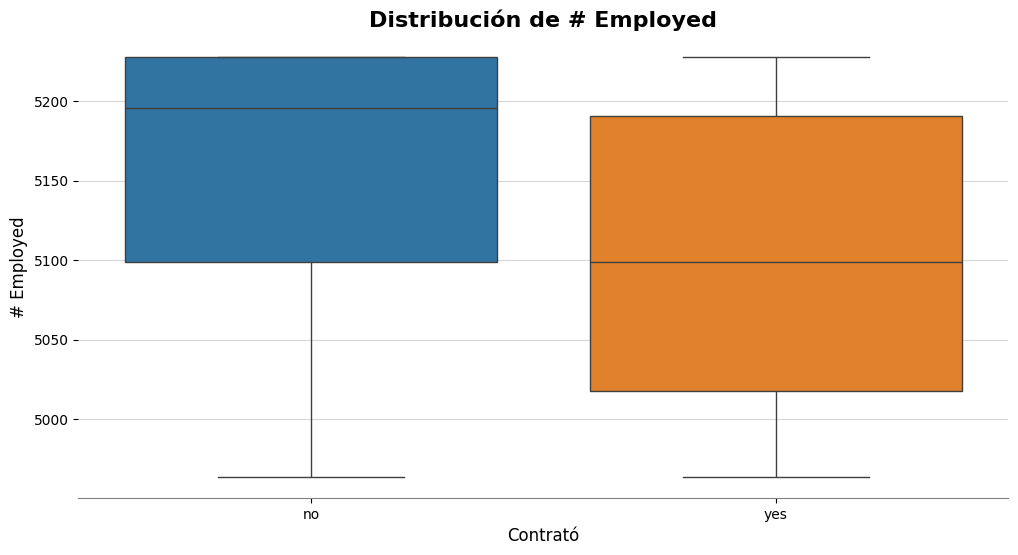

In [27]:
# TODO: configurar tamaño del plot (figsize=(12,6))
plt.figure(figsize=(12, 6))

# TODO: boxplot ventas vs mes
ax = sns.boxplot(
    data=df,
    y="nr.employed",
    x="y",
    hue="y",
    legend=False
    )

# TODO: añadir título al plot y a los ejes
ax.set_title("Distribución de # Employed", fontsize=16, fontweight="bold")
ax.set_xlabel("Contrató", fontsize=12)
ax.set_ylabel("# Employed", fontsize=12)

# TODO: personalizar el grid de fondo
ax.grid(alpha=0.5, drawstyle="steps", axis="y", linestyle="-")

# TODO: personalizar el marco del plot (spines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("gray")

# TODO: show plot
plt.show()

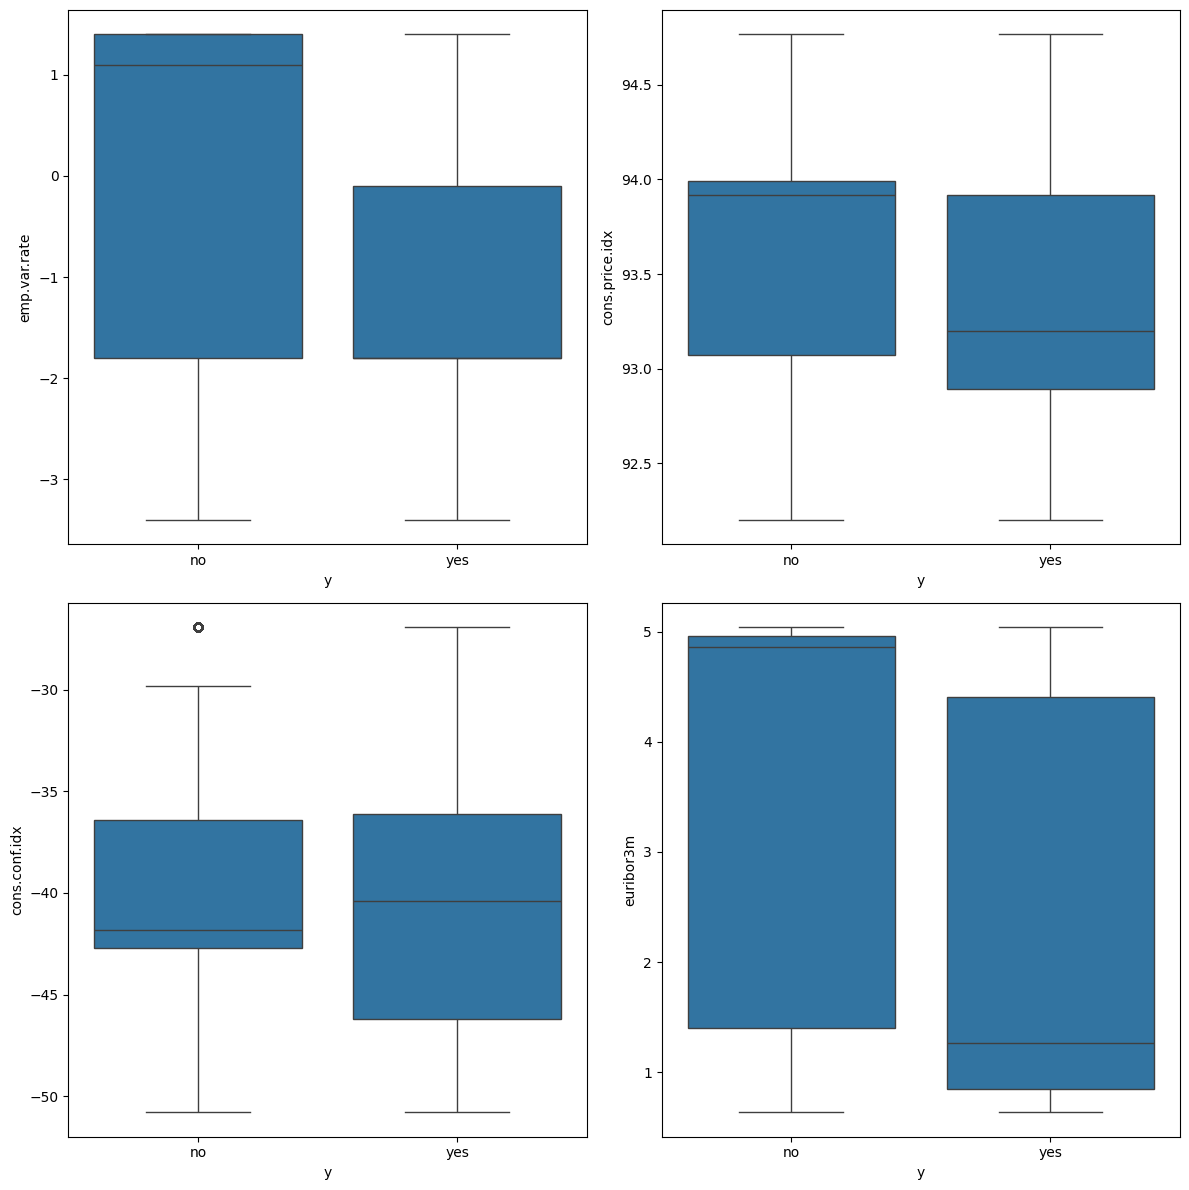

In [28]:
# TODO: iniciar el grid para el plot (3, 3, figsize=(12, 6))
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# TODO: aplanar todos los axes para poder recorrerlos todos en un solo bucle
axes_flat = axes.flatten()

# TODO: pintar cada scatterplot de forma 
lag_cols = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

for i, ax in enumerate(axes_flat):
    sns.boxplot(
        data=df,
        y=lag_cols[i],
        x="y",
        legend=False,
        ax=ax,  # pintamos sobre un ax ya existente
        )
    
# TODO: ajustar espacio entre plots
plt.tight_layout()

[⬆ Volver al índice](#indice)

<a id="analisis"></a>
## Análisis de los datos 🧠

### Tasa de Conversión Total

La tasa de conversión total de la campaña es **11%.**

In [29]:
(df.query('y == "yes"')['y'].count() / df['y'].count()).round(2)

np.float64(0.11)

### Empleos

Cúales tipos de empleos tienen las personas contactadas, y cúanta gente en total hay en cada grupo?

In [30]:
df.groupby('job')['y'].count().reset_index().rename({'y':'contacts'}, axis = 'columns').sort_values(by = 'contacts', ascending= False)

,job,contacts
0,admin.,10422
1,blue-collar,9254
9,technician,6743
7,services,3969
4,management,2924
5,retired,1720
2,entrepreneur,1456
6,self-employed,1421
3,housemaid,1060
10,unemployed,1014


<Axes: xlabel='y', ylabel='job'>

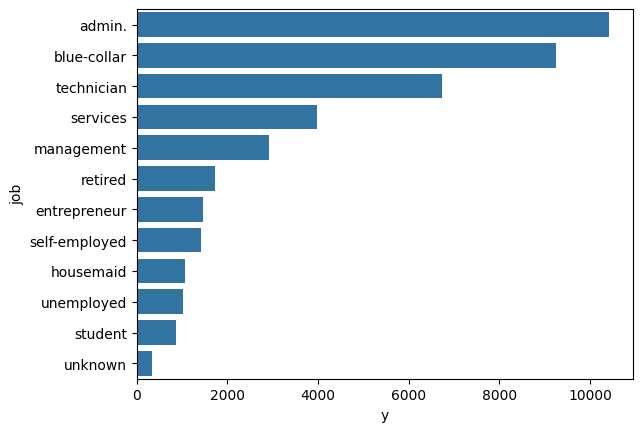

In [31]:
df.groupby('job')['y'].count()

# df.groupby('job')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job', columns = 'y', values = 'proportion')

sns.barplot(
    df.groupby('job')['y'].count().reset_index().sort_values(by = 'y', ascending= False),
    x = 'y',
    y = 'job'
)

# euribor3m	

Qué es la proporción de gente que dijó "Sí" basado a nuestro contacto, por trabajo?

In [32]:
df.groupby('job')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job', columns = 'y', values = 'proportion')

y,no,yes
job,,
admin.,0.87,0.13
blue-collar,0.93,0.07
entrepreneur,0.91,0.09
housemaid,0.90,0.10
management,0.89,0.11
retired,0.75,0.25
self-employed,0.90,0.10
services,0.92,0.08
student,0.69,0.31


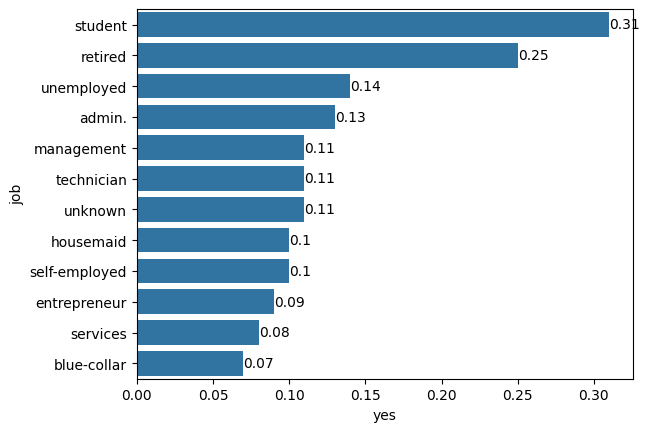

In [33]:
ax = sns.barplot(
    df.groupby('job')['y']
      .value_counts(normalize=True)
      .round(2)
      .reset_index()
      .pivot(index='job', columns='y', values='proportion')
      .sort_values(by='yes', ascending=False),
    x='yes',
    y='job'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

In [34]:
# Creando un nuevo campo.
df['job_type'] = df['job'].apply(lambda x: jobType(x))


In [35]:
print(df.groupby('job_type')['y'].count())
print('--'*20)
print(df['job_type'].value_counts(normalize= True).round(2))
print('--'*20)
print(df.query('y == "yes"')['job_type'].value_counts(normalize = True).round(2))

job_type
No Job or Student     1889
Office Job           17315
Physical Job         17057
Retired               1720
Self-Employed         2877
Unknown                330
Name: y, dtype: int64
----------------------------------------
job_type
Office Job           0.42
Physical Job         0.41
Self-Employed        0.07
No Job or Student    0.05
Retired              0.04
Unknown              0.01
Name: proportion, dtype: float64
----------------------------------------
job_type
Office Job           0.43
Physical Job         0.32
Retired              0.09
No Job or Student    0.09
Self-Employed        0.06
Unknown              0.01
Name: proportion, dtype: float64


[Text(0, 0, '0.25'),
 Text(0, 0, '0.22'),
 Text(0, 0, '0.12'),
 Text(0, 0, '0.11'),
 Text(0, 0, '0.09'),
 Text(0, 0, '0.09')]

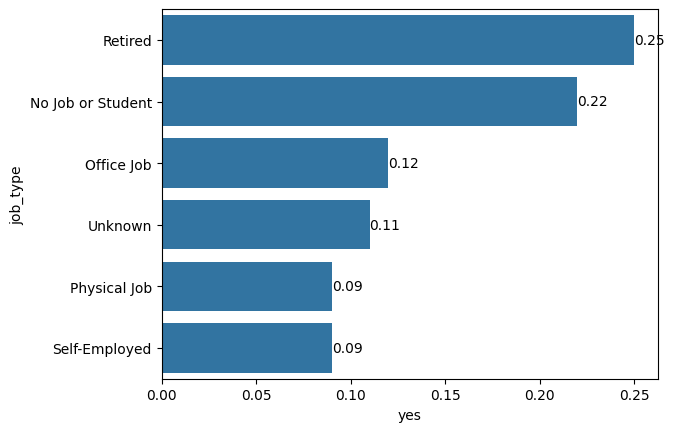

In [36]:
ax = sns.barplot(
    df.groupby('job_type')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job_type', columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job_type'
)

ax.bar_label(ax.containers[0], fontsize=10)


### Educación

In [37]:
# Creando un campo para analisar tipo de educación.
df['education_type'] = df['education'].apply(lambda x: educationType(x))


In [38]:
print(df.groupby('education_type')['y'].count())
print('--'*20)
print(df['education_type'].value_counts(normalize= True).round(2))
print('--'*20)
print(df.query('y == "yes"')['education_type'].value_counts(normalize = True).round(2))

education_type
Basic Education (Yr 4-9)              12513
High School                            9515
University or Professional Program    17411
Unknown or Illiterate                  1749
Name: y, dtype: int64
----------------------------------------
education_type
University or Professional Program    0.42
Basic Education (Yr 4-9)              0.30
High School                           0.23
Unknown or Illiterate                 0.04
Name: proportion, dtype: float64
----------------------------------------
education_type
University or Professional Program    0.49
Basic Education (Yr 4-9)              0.23
High School                           0.22
Unknown or Illiterate                 0.05
Name: proportion, dtype: float64


[Text(0, 0, '0.22'),
 Text(0, 0, '0.15'),
 Text(0, 0, '0.14'),
 Text(0, 0, '0.11'),
 Text(0, 0, '0.11'),
 Text(0, 0, '0.1'),
 Text(0, 0, '0.08'),
 Text(0, 0, '0.08')]

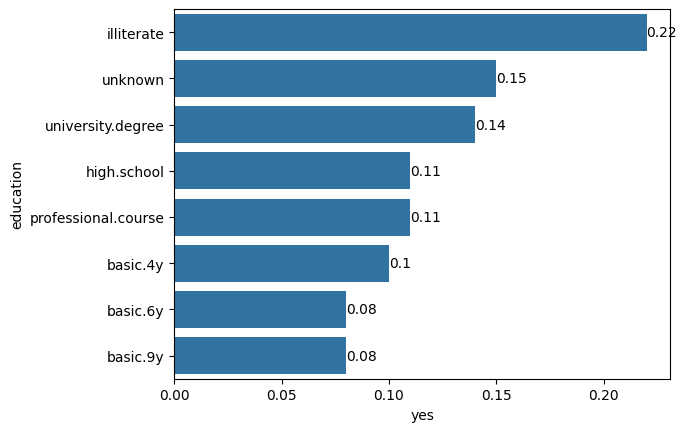

In [39]:
ax = sns.barplot(
    df.groupby('education')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'education', columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'education'
)

ax.bar_label(ax.containers[0], fontsize=10)



[Text(0, 0, '0.15'),
 Text(0, 0, '0.09'),
 Text(0, 0, '0.11'),
 Text(0, 0, '0.13')]

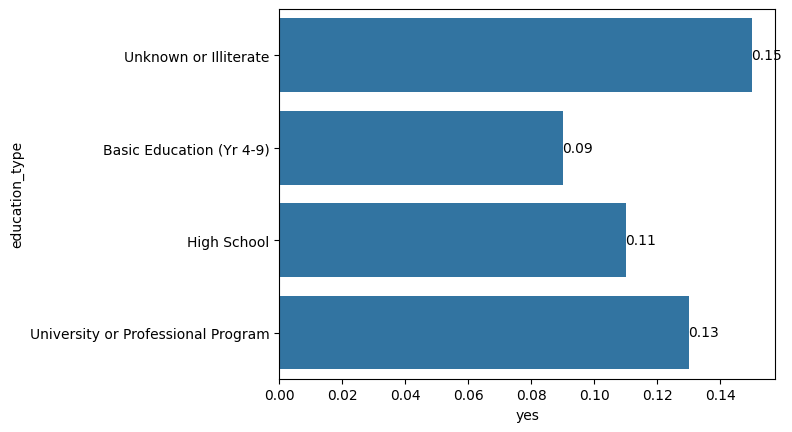

In [40]:
ax = sns.barplot(
    df.groupby('education_type')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'education_type', columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'education_type',
        order= ['Unknown or Illiterate','Basic Education (Yr 4-9)','High School','University or Professional Program']
)

ax.bar_label(ax.containers[0], fontsize=10)


### Modo de Contacto

<Axes: xlabel='proportion', ylabel='contact'>

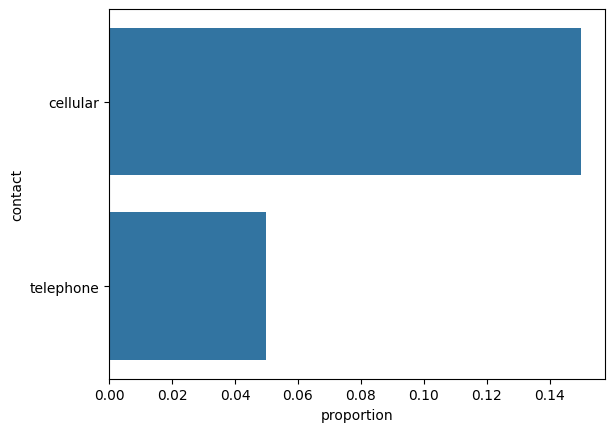

In [41]:
sns.barplot(
    df.groupby(['contact'])['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x = 'proportion',
    y = 'contact'
)

<Axes: xlabel='yes', ylabel='job_type'>

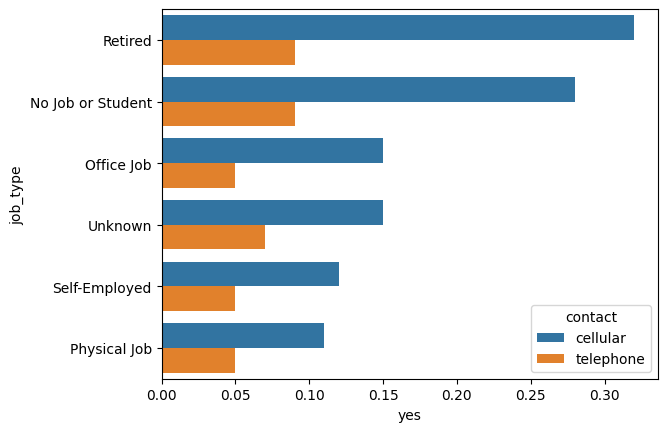

In [42]:
sns.barplot(
    df.groupby(['job_type','contact'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['job_type','contact'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job_type',
    hue = 'contact'
)

<Axes: xlabel='yes', ylabel='education_type'>

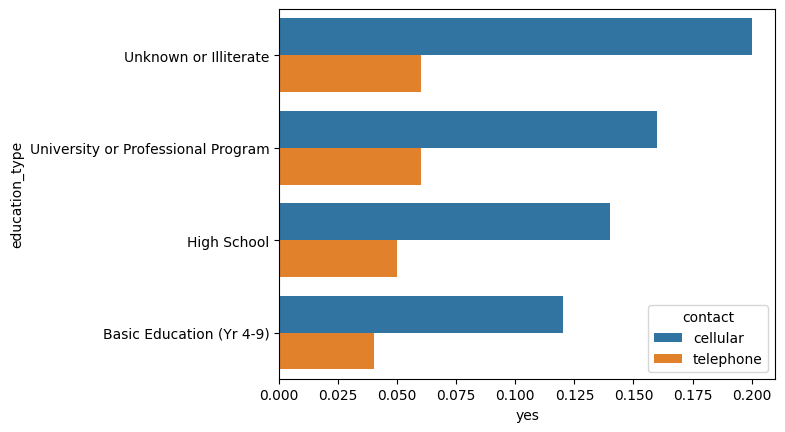

In [43]:
sns.barplot(
    df.groupby(['education_type','contact'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['education_type','contact'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'education_type',
    hue = 'contact'
)

[Text(0, 0, '0.14'), Text(0, 0, '0.1'), Text(0, 0, '0.1')]

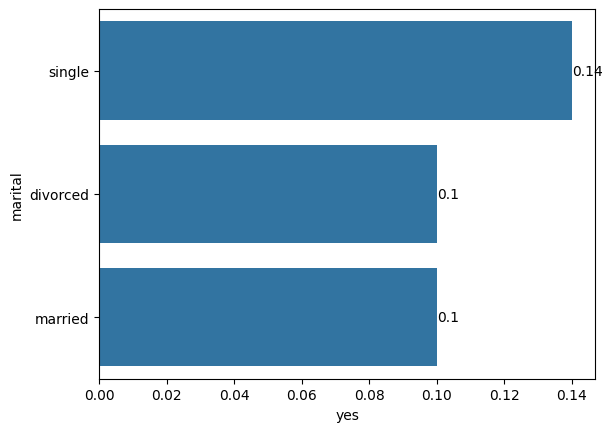

In [44]:
ax = sns.barplot(
    df.query('marital != "unknown"').groupby('marital')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'marital', columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'marital'
)

ax.bar_label(ax.containers[0], fontsize=10)



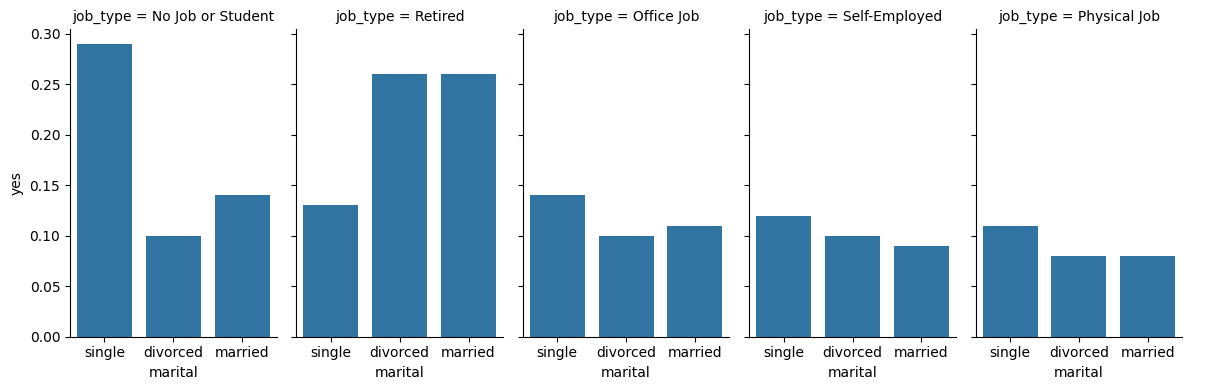

In [45]:
# Unknown represents 80 out of 41k columns. Remove. Also removing unknown job people since that is also less than 1%.

sns.catplot(
    data= df.query('job != "unknown"').groupby(['marital','job_type'])['y'].value_counts(normalize= True).round(2).reset_index().query('marital != "unknown"').pivot(index= ['marital','job_type'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "marital", 
    y= "yes", 
    col= "job_type",
    kind="bar", height=4, aspect=.6,
)

In [46]:
df.groupby('marital')['y'].count()

marital
divorced     4612
married     24928
single      11568
unknown        80
Name: y, dtype: int64

#### Duración de Llamada

In [47]:
df['duration_minutes'] = df['duration'] / 60

In [48]:
df.duration.describe() / 60

count    686.466667
mean       4.304750
std        4.321321
min        0.000000
25%        1.700000
50%        3.000000
75%        5.316667
max       81.966667
Name: duration, dtype: float64

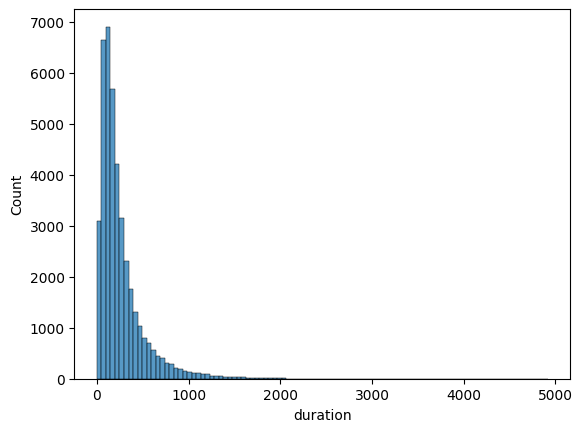

In [49]:
fig = sns.histplot(
    data=df, 
    x="duration",
    bins= 100
    )


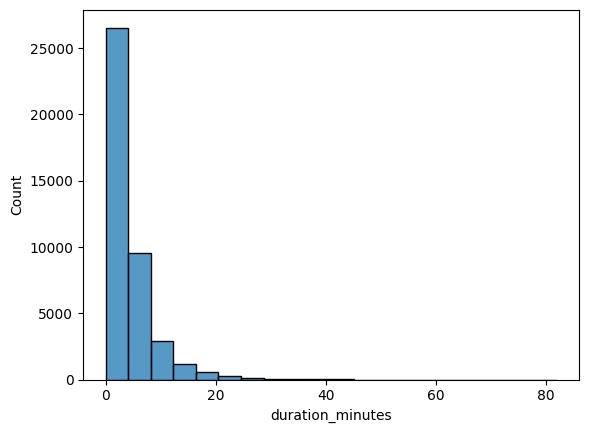

In [50]:
fig = sns.histplot(
    data=df, 
    x="duration_minutes",
    bins= 20
    )


C:\Users\migue\AppData\Local\Temp\ipykernel_1504\3020444794.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('duration_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'duration_segment', columns = 'y', values = 'proportion'),


<Axes: xlabel='yes', ylabel='duration_segment'>

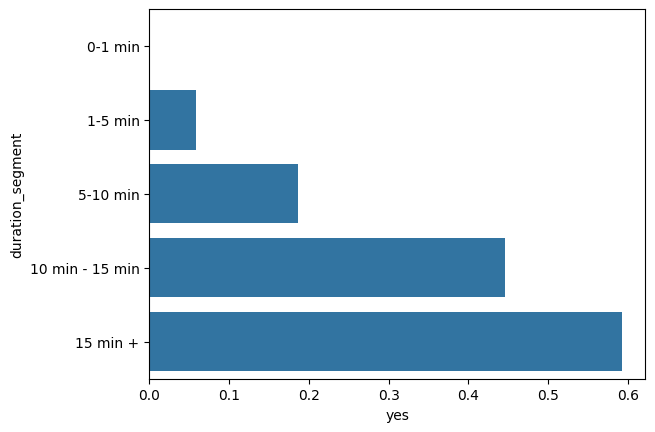

In [51]:
bins = [0, 60, 300, 600, 1000, np.inf]
names = ['0-1 min', '1-5 min', '5-10 min', '10 min - 15 min','15 min +']

df['duration_segment'] = pd.cut(df['duration'], bins, labels=names)

sns.barplot(
    df.groupby('duration_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'duration_segment', columns = 'y', values = 'proportion'),
    x = 'yes',
    y = 'duration_segment'
)

In [52]:
print('-'*5 + 'Number of total contacts' + '-' *5)
print(df.groupby('duration_segment')['y'].count().sort_values())
print('-'*5 + 'Proportion of total contacts' + '-' *5)
print(df['duration_segment'].value_counts(normalize= True).round(2))
print('-'*5 + 'Number of total successful contacts' + '-' *5)
print(df.query('y == "yes"')['duration_segment'].value_counts().sort_values())
print('-'*5 + 'Proportion of total successful clients' + '-' *5)
print(df.query('y == "yes"')['duration_segment'].value_counts(normalize = True).round(2))

-----Number of total contacts-----
duration_segment
15 min +             956
10 min - 15 min     2508
0-1 min             4282
5-10 min            7740
1-5 min            25698
Name: y, dtype: int64
-----Proportion of total contacts-----
duration_segment
1-5 min            0.62
5-10 min           0.19
0-1 min            0.10
10 min - 15 min    0.06
15 min +           0.02
Name: proportion, dtype: float64
-----Number of total successful contacts-----
duration_segment
0-1 min               1
15 min +            566
10 min - 15 min    1118
5-10 min           1438
1-5 min            1517
Name: count, dtype: int64
-----Proportion of total successful clients-----
duration_segment
1-5 min            0.33
5-10 min           0.31
10 min - 15 min    0.24
15 min +           0.12
0-1 min            0.00
Name: proportion, dtype: float64


C:\Users\migue\AppData\Local\Temp\ipykernel_1504\3389528216.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('duration_segment')['y'].count().sort_values())


### Intentos Previos

In [53]:
df['previously_attempted'] = df['previous'].apply(lambda x: previouslyContacted(x))


In [54]:
df['previously_attempted'].value_counts()

previously_attempted
Prospect       35563
Retargeting     5625
Name: count, dtype: int64

[Text(0, 0, '0.09')]

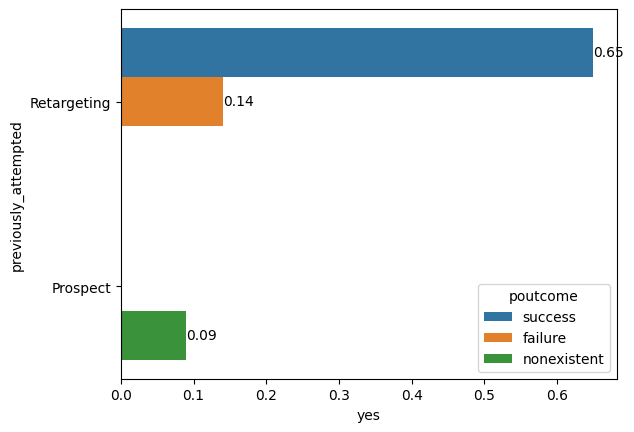

In [55]:
ax = sns.barplot(
    df.groupby(['previously_attempted','poutcome'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','poutcome'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'previously_attempted',
    hue = 'poutcome',
)

ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)



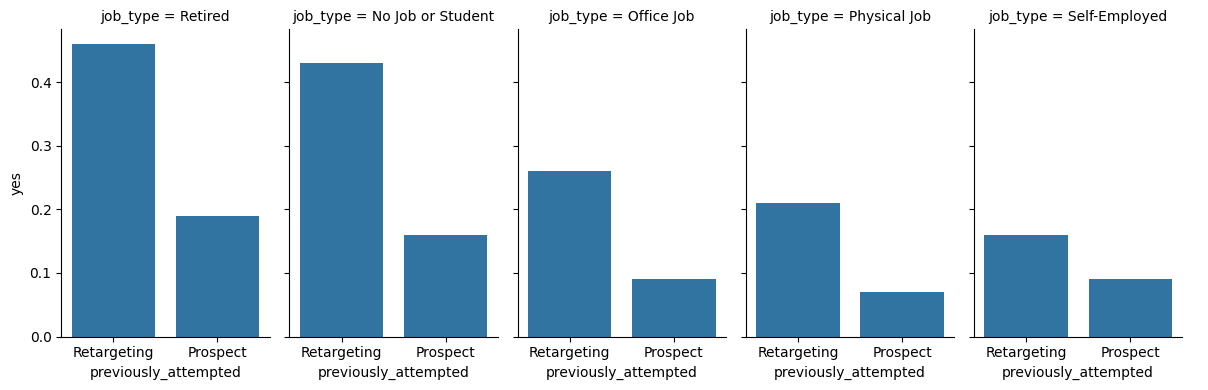

In [56]:


sns.catplot(
    data= df.query('job != "unknown"').groupby(['previously_attempted','job_type'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','job_type'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "previously_attempted", 
    y= "yes", 
    col= "job_type",
    kind="bar", height=4, aspect=.6
)

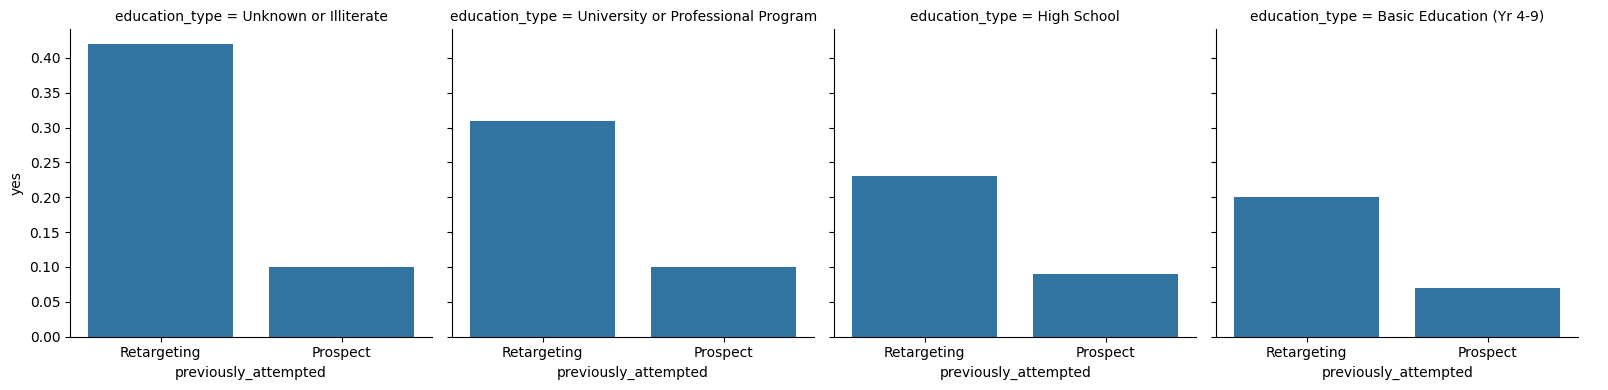

In [57]:
sns.catplot(
    data= df.groupby(['previously_attempted','education_type'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','education_type'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "previously_attempted", 
    y= "yes", 
    col= "education_type",
    kind="bar", height=4, aspect=1
)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\3134728012.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data= df.groupby(['previously_attempted','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),


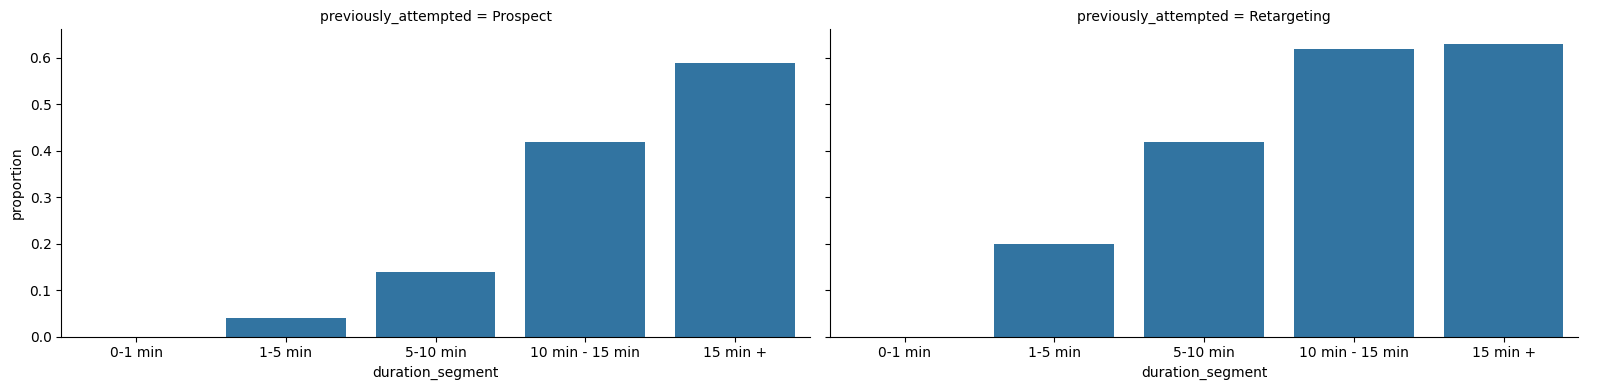

In [58]:
sns.catplot(
    data= df.groupby(['previously_attempted','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x= "duration_segment", 
    y= "proportion", 
    col= "previously_attempted",
    kind="bar", height=4, aspect=2
)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\1011131199.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data= df.groupby(['previously_attempted','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','duration_segment'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),


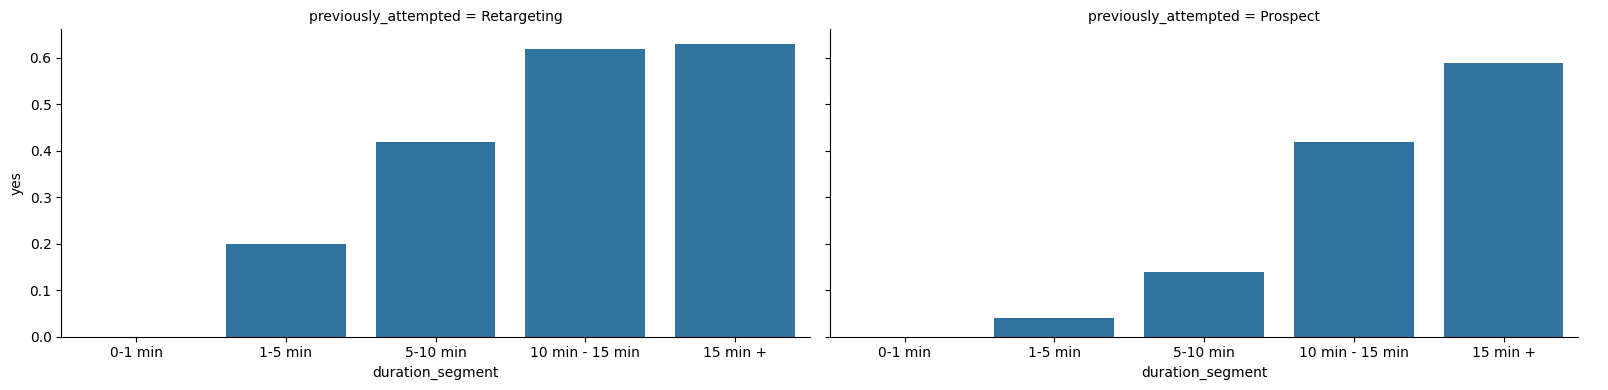

In [59]:
sns.catplot(
    data= df.groupby(['previously_attempted','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','duration_segment'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "duration_segment", 
    y= "yes", 
    col= "previously_attempted",
    kind="bar", height=4, aspect=2
)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\721074314.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data= df.groupby(['previously_attempted','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','duration_segment'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),


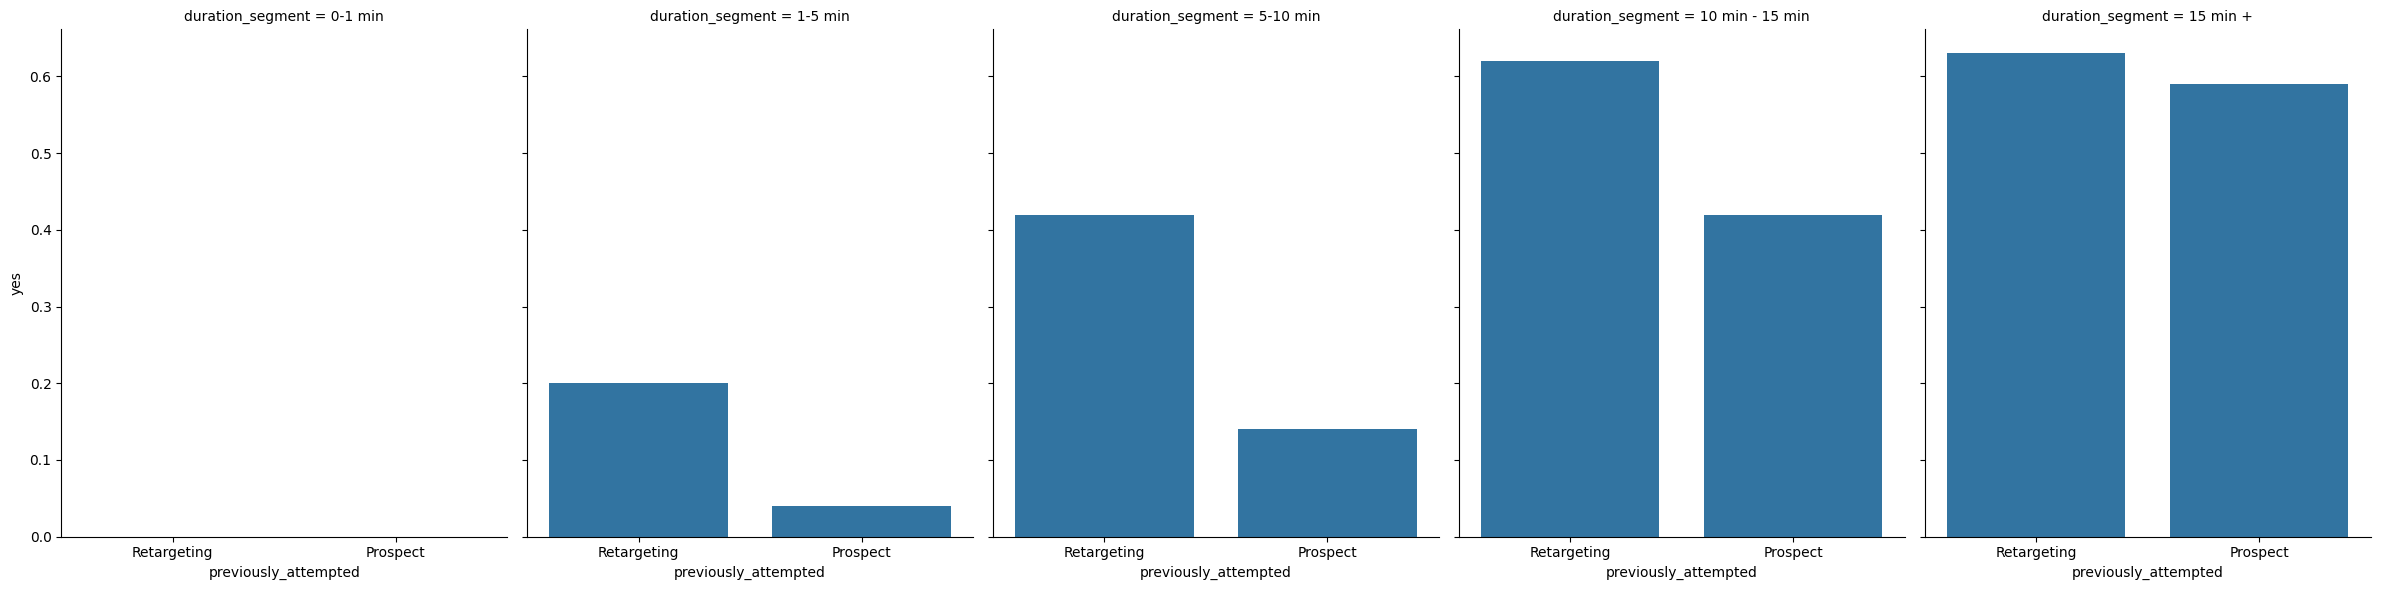

In [60]:
sns.catplot(
    data= df.groupby(['previously_attempted','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','duration_segment'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "previously_attempted", 
    y= "yes", 
    col= "duration_segment",
    kind="bar", height=6, aspect=0.8
)

In [61]:
(df.groupby(['previously_attempted','y'])['duration_minutes'].mean()).reset_index().pivot(index= 'previously_attempted', columns = 'y', values= 'duration_minutes')

y,no,yes
previously_attempted,,
Prospect,3.692764,10.394811
Retargeting,3.586314,6.757850


In [62]:
df.query('previously_attempted == "Prospect"').groupby(['job_type','y'])['duration_minutes'].mean().round(2).reset_index().pivot(index= 'job_type', columns = 'y', values = 'duration_minutes')

y,no,yes
job_type,,
No Job or Student,3.70,7.88
Office Job,3.64,10.08
Physical Job,3.73,11.74
Retired,3.76,7.77
Self-Employed,3.77,11.47
Unknown,3.30,11.32


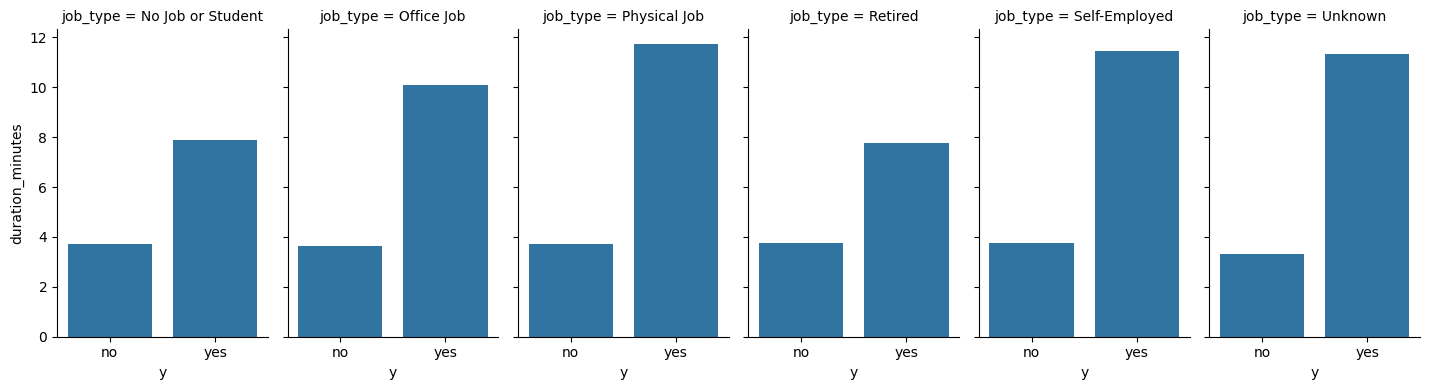

In [63]:
sns.catplot(
    data= df.query('previously_attempted == "Prospect"').groupby(['job_type','y'])['duration_minutes'].mean().round(2).reset_index(),
    x= "y", 
    y= "duration_minutes", 
    col= "job_type",
    kind="bar", height=4, aspect=.6,
)

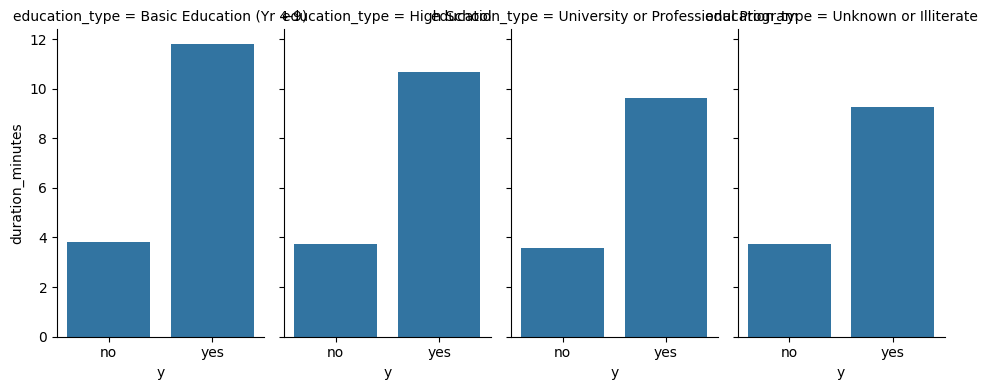

In [64]:
sns.catplot(
    data= df.query('previously_attempted == "Prospect"').groupby(['education_type','y'])['duration_minutes'].mean().round(2).reset_index(),
    x= "y", 
    y= "duration_minutes", 
    col= "education_type",
    kind="bar", height=4, aspect=.6,
)

### Otros Prestamos

[Text(0, 0, '0.25'), Text(0, 0, '0.09')]

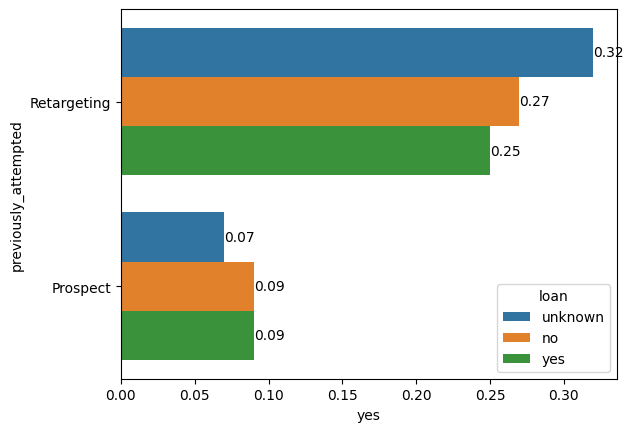

In [65]:
ax = sns.barplot(
    df.groupby(['previously_attempted','loan'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','loan'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'previously_attempted',
    hue = 'loan',
)

ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)



C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2076951354.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data= df.groupby(['loan','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['loan','duration_segment'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),


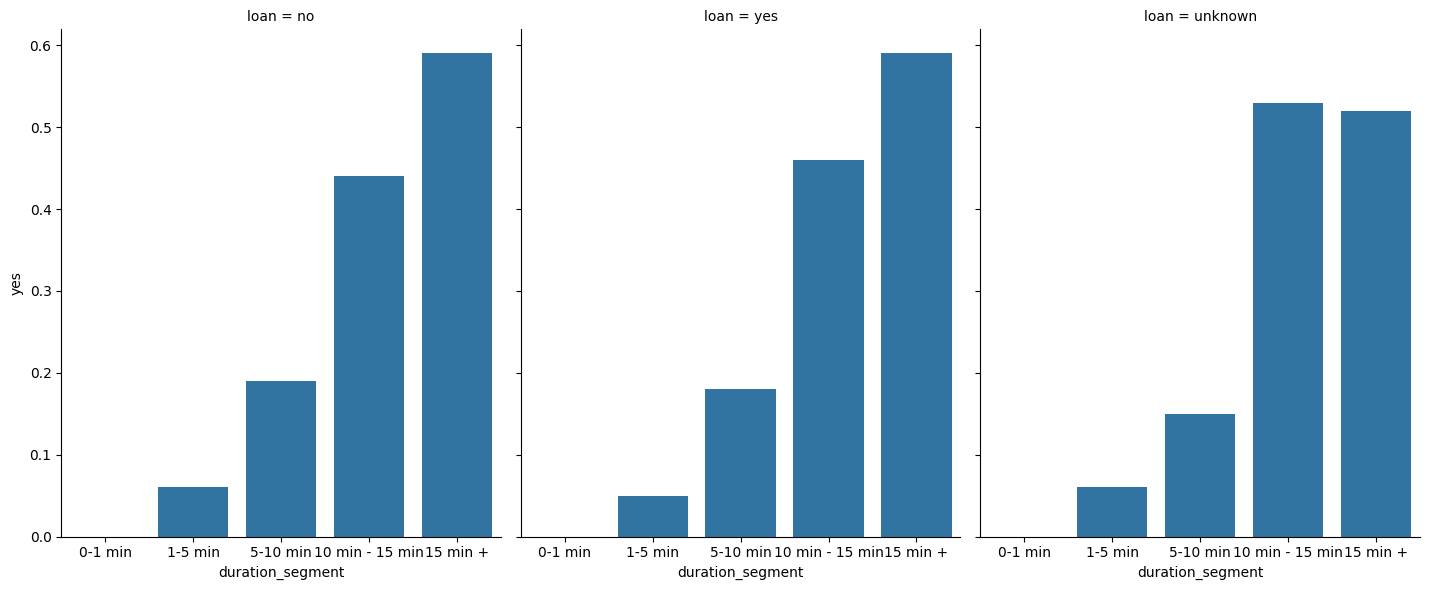

In [66]:
sns.catplot(
    data= df.groupby(['loan','duration_segment'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['loan','duration_segment'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "duration_segment", 
    y= "yes", 
    col= "loan",
    kind="bar", height=6, aspect=0.8
)

[Text(0, 0, '0.26'), Text(0, 0, '0.09')]

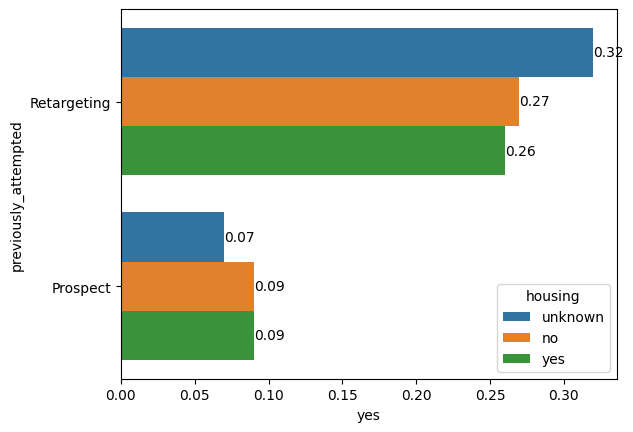

In [67]:
ax = sns.barplot(
    df.groupby(['previously_attempted','housing'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','housing'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'previously_attempted',
    hue = 'housing',
)

ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)



[]

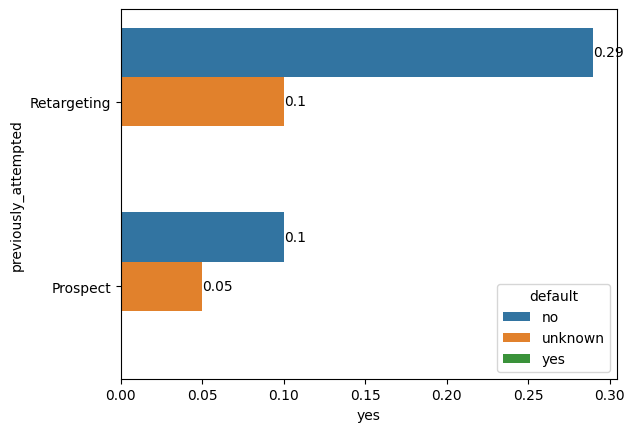

In [68]:
ax = sns.barplot(
    df.groupby(['previously_attempted','default'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','default'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'previously_attempted',
    hue = 'default',
)

ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
ax.bar_label(ax.containers[2], fontsize=10)



In [69]:
df.groupby('default')['y'].count()

default
no         32588
unknown     8597
yes            3
Name: y, dtype: int64

### Campaña Corriente - Mes o Día de la Semana y Cuantas veces hemos contactado

In [70]:
df.month.value_counts()

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [71]:
df['season'] = df['month'].apply(lambda x: seasons(x))

In [72]:
print(df.season.value_counts())
print('--'*20)
print(df.season.value_counts(normalize= True).round(2))


season
Spring    21719
Summer    13922
Otoño      5001
Winter      546
Name: count, dtype: int64
----------------------------------------
season
Spring    0.53
Summer    0.34
Otoño     0.12
Winter    0.01
Name: proportion, dtype: float64


<Axes: xlabel='proportion', ylabel='season'>

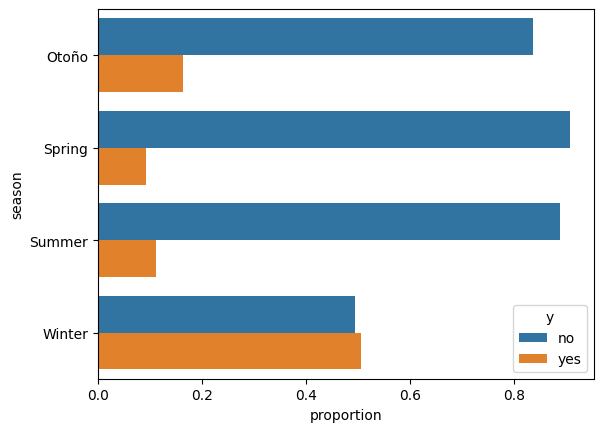

In [73]:
sns.barplot(
    df.groupby('season')['y'].value_counts(normalize= True).reset_index(),
    x = 'proportion',
    y = 'season',
    hue = 'y'
)

<Axes: xlabel='proportion', ylabel='day_of_week'>

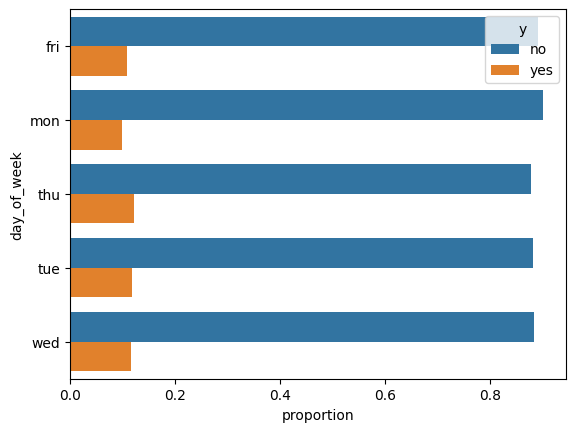

In [74]:
sns.barplot(
    df.groupby('day_of_week')['y'].value_counts(normalize= True).reset_index(),
    x = 'proportion',
    y = 'day_of_week',
    hue = 'y'
)
# .pivot(index= 'day_of_week', columns = 'y', values = 'proportion')

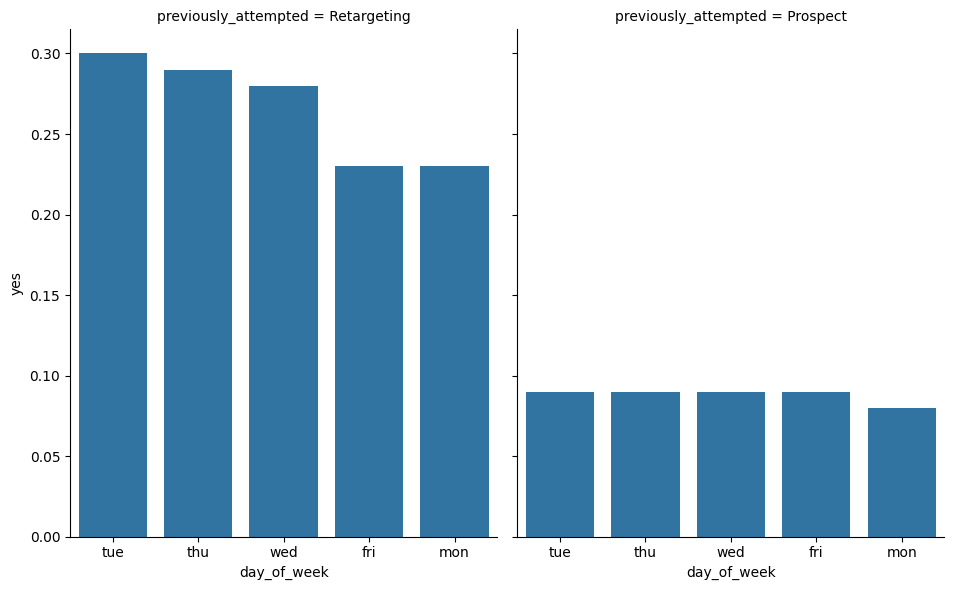

In [75]:
sns.catplot(
    data= df.groupby(['day_of_week','previously_attempted'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['day_of_week','previously_attempted'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "day_of_week", 
    y= "yes", 
    col= "previously_attempted",
    kind="bar", height=6, aspect=0.8
)

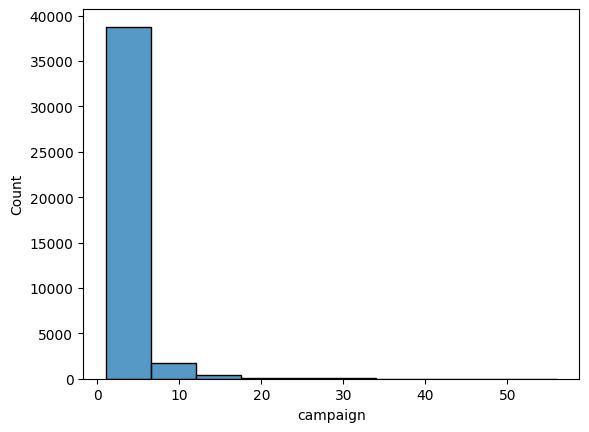

In [76]:
fig = sns.histplot(
    data=df, 
    x="campaign",
    bins = 10
    )


In [77]:
bins = [0,1,2,5,10,np.inf]
names = ['0 times', '1x', '2-5x', '5-10x','10x +']

df['campaign_segment'] = pd.cut(df['campaign'], bins, labels=names)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\4013030521.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['campaign_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),


<Axes: xlabel='campaign_segment', ylabel='proportion'>

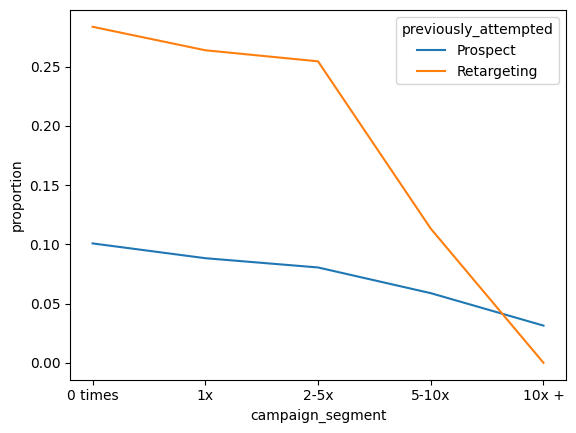

In [78]:
sns.lineplot(
    df.groupby(['campaign_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),
    x = 'campaign_segment',
    y = 'proportion',
    hue = 'previously_attempted'
)


C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2262566396.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data= df.groupby(['campaign_segment','duration_segment','previously_attempted'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['campaign_segment','duration_segment','previously_attempted'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),


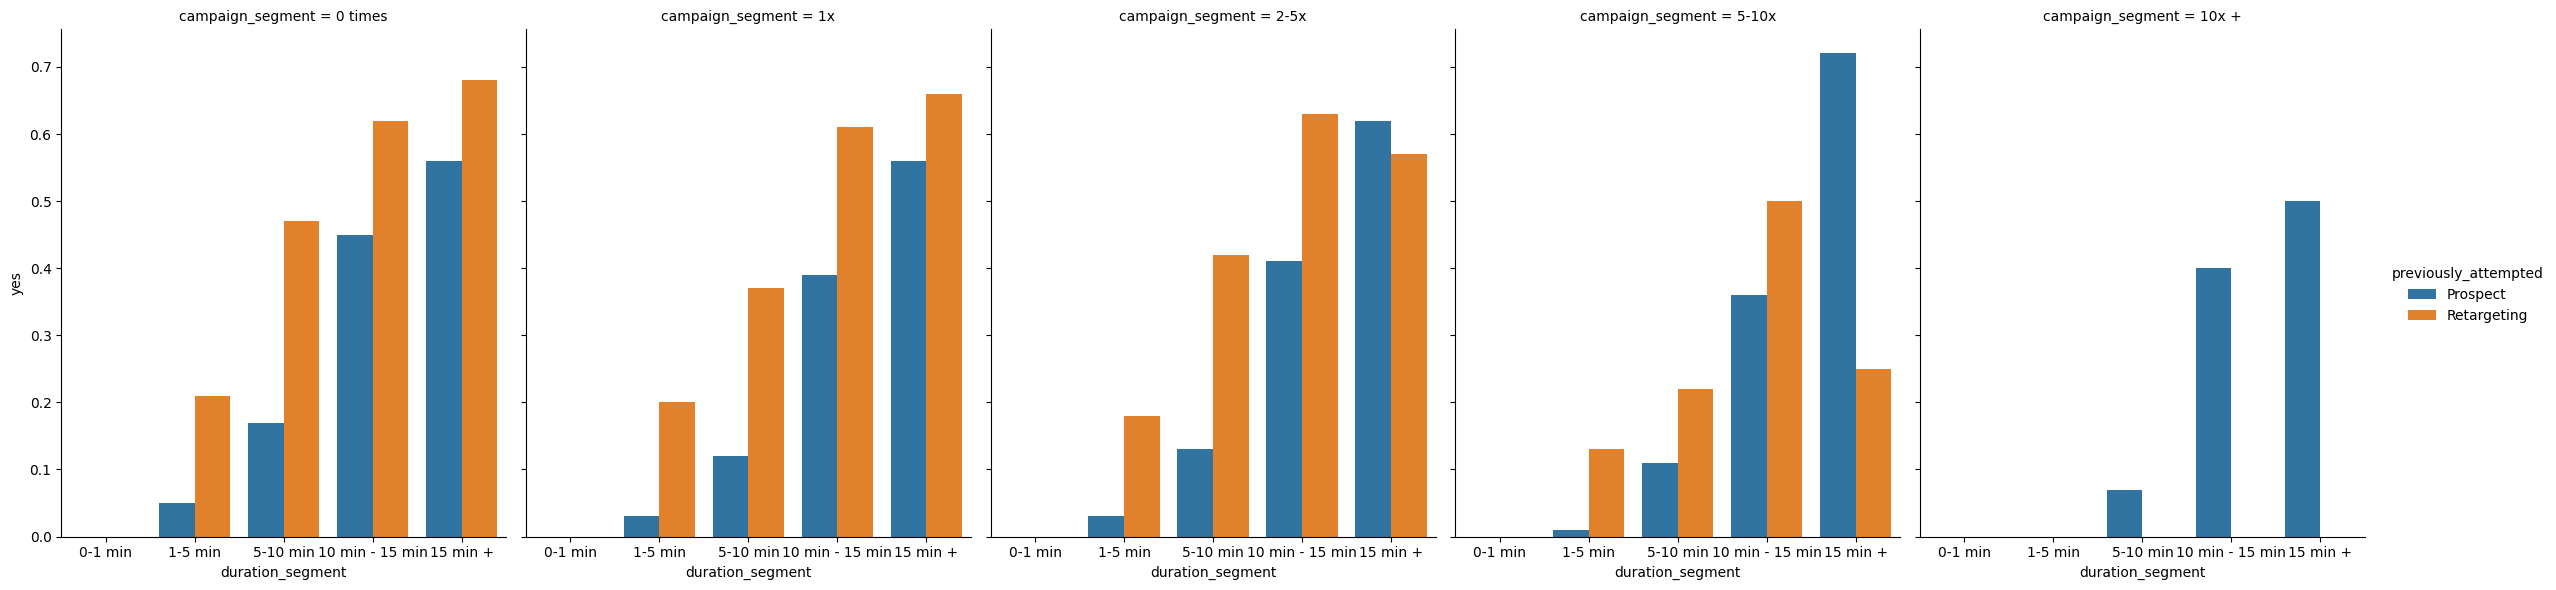

In [79]:
sns.catplot(
    data= df.groupby(['campaign_segment','duration_segment','previously_attempted'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['campaign_segment','duration_segment','previously_attempted'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "duration_segment", 
    y= "yes", 
    col= "campaign_segment",
    hue= 'previously_attempted',
    kind="bar", height=6, aspect=0.8
)

#### Edad

<Axes: xlabel='age', ylabel='proportion'>

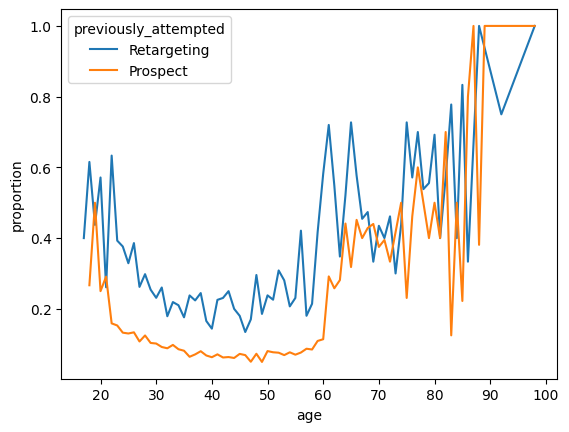

In [80]:
sns.lineplot(
    df.groupby(['age','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),
    x = 'age',
    y = 'proportion',
    hue = 'previously_attempted'
)


In [81]:
bins = [0,25, 35, 45, 55, 65, np.inf]
names = ['0-25', '25-35', '35-45', '45-55','55-65','65+']

df['age_segment'] = pd.cut(df['age'], bins, labels=names)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2403347628.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),


<Axes: xlabel='age_segment', ylabel='proportion'>

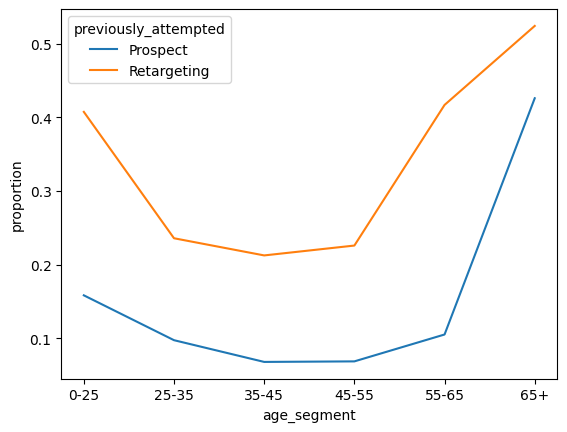

In [82]:
sns.lineplot(
    df.groupby(['age_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),
    x = 'age_segment',
    y = 'proportion',
    hue = 'previously_attempted'
)


##

In [83]:
df.euribor3m.describe()

count    41188.000000
mean         3.621291
std          1.734447
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64

In [84]:
import numpy as np

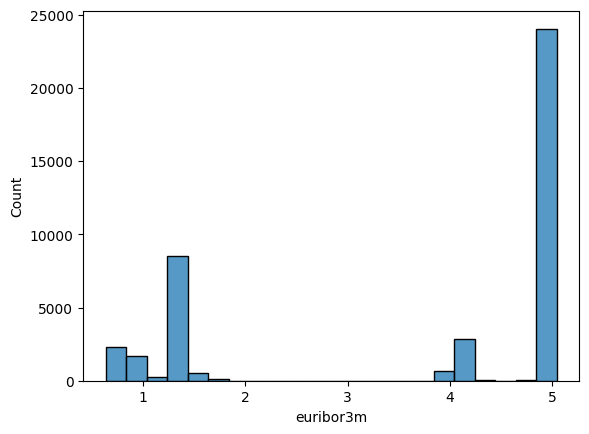

In [85]:
fig = sns.histplot(
    data=df, 
    x="euribor3m"
    )


In [86]:
bins = [0, 2, 3, 4.5, 5.5]
names = ['0-2', '2-3', '3-4.5', '4.5-5.5']

df['euribor3m_segment'] = pd.cut(df['euribor3m'], bins, labels=names)

In [87]:
df.groupby('euribor3m_segment')['y'].count()

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2533331586.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('euribor3m_segment')['y'].count()


euribor3m_segment
0-2        13498
2-3            0
3-4.5       3603
4.5-5.5    24087
Name: y, dtype: int64

In [88]:
df.groupby('euribor3m_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'euribor3m_segment', columns = 'y', values = 'proportion').round(2)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2885295832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('euribor3m_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'euribor3m_segment', columns = 'y', values = 'proportion').round(2)


y,no,yes
euribor3m_segment,,
0-2,0.76,0.24
2-3,0.00,0.00
3-4.5,0.95,0.05
4.5-5.5,0.95,0.05


C:\Users\migue\AppData\Local\Temp\ipykernel_1504\1559798075.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('euribor3m_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'euribor3m_segment', columns = 'y', values = 'proportion'),


"\nbins = [0, 2, 18, 35, 65, np.inf]\nnames = ['<2', '2-18', '18-35', '35-65', '65+']\n\n\n\nprint(df.dtypes)\n\n# Age             int64\n# Age_units      object\n# AgeRange     category\n# dtype: object\n\n"

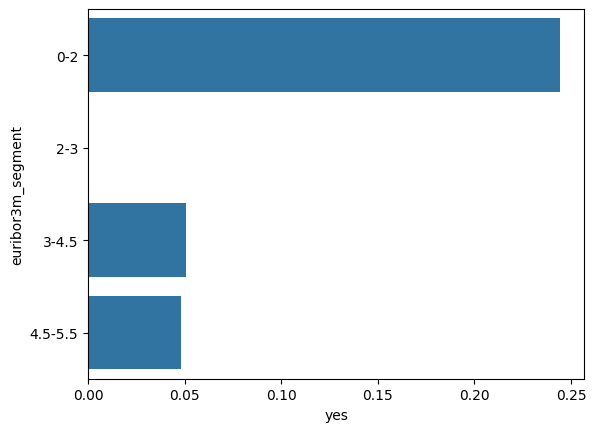

In [89]:
sns.barplot(
    df.groupby('euribor3m_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'euribor3m_segment', columns = 'y', values = 'proportion'),
    x = 'yes',
    y = 'euribor3m_segment'
)


"""
bins = [0, 2, 18, 35, 65, np.inf]
names = ['<2', '2-18', '18-35', '35-65', '65+']



print(df.dtypes)

# Age             int64
# Age_units      object
# AgeRange     category
# dtype: object

"""

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\206303089.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('euribor3m_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'euribor3m_segment', columns = 'y', values = 'proportion'),


<Axes: xlabel='euribor3m_segment', ylabel='yes'>

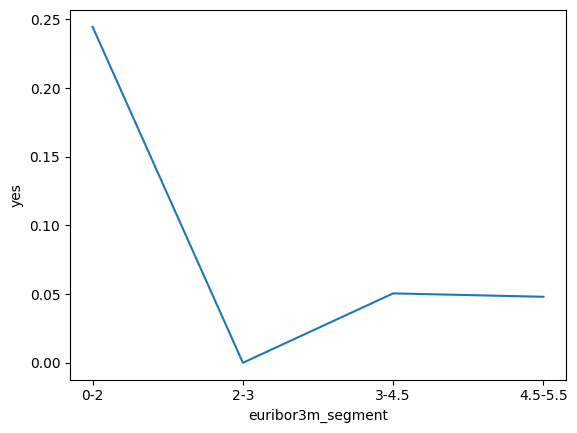

In [90]:
sns.lineplot(
    df.groupby('euribor3m_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'euribor3m_segment', columns = 'y', values = 'proportion'),
    x = 'euribor3m_segment',
    y = 'yes'
)


C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2596561446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'age_segment', columns = 'y', values = 'proportion'),


<Axes: xlabel='yes', ylabel='age_segment'>

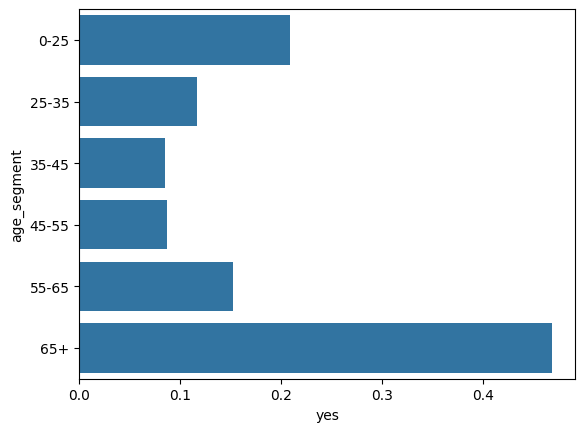

In [91]:
bins = [0,25, 35, 45, 55, 65, np.inf]
names = ['0-25', '25-35', '35-45', '45-55','55-65','65+']

df['age_segment'] = pd.cut(df['age'], bins, labels=names)

sns.barplot(
    df.groupby('age_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'age_segment', columns = 'y', values = 'proportion'),
    x = 'yes',
    y = 'age_segment'
)

In [92]:
df.groupby('age_segment')['y'].count()

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\673053720.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_segment')['y'].count()


age_segment
0-25      1666
25-35    14847
35-45    12844
45-55     8249
55-65     2963
65+        619
Name: y, dtype: int64

### Duracion de las llamadas

In [93]:
# voy a quitar los outliers de la duration ya que pueden crear malentendidos
limite_inferior, limite_superior = limites_outliers(df,'duration')

Valor del segundo cuartil (25%): 102.00
Valor del tercer cuartil (75%): 319.00
Valor del rango intercuartil (IQR): 217.00
Los valores atípicos se definen como aquellos que caen fuera del siguiente rango:
	 - Límite inferior (considerado extremadamente bajo): -223.50
	 - Límite superior (considerado extremadamente alto): 644.50


In [94]:
df_sin_outliers = df[(df['duration'] >= limite_inferior) & (df['duration'] <= limite_superior)]

<Axes: xlabel='duration', ylabel='y'>

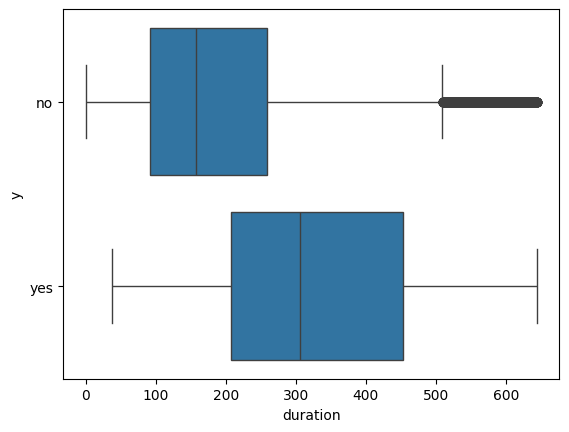

In [95]:
sns.boxplot(x='duration', y='y', data=df_sin_outliers)

In [96]:
pd.crosstab(df_sin_outliers['job'] , df_sin_outliers['duration'])

duration,0,1,2,3,4,5,6,7,8,9,...,635,636,637,638,639,640,641,642,643,644
job,,,,,,,,,,,,,,,,,,,,,
admin.,1,0,0,1,5,7,11,17,16,22,...,3,2,1,5,4,0,4,2,6,2
blue-collar,2,1,0,1,3,8,4,12,16,17,...,3,2,3,1,0,2,2,2,2,2
entrepreneur,0,0,1,0,0,1,1,4,6,4,...,0,1,1,1,1,0,1,1,0,0
housemaid,0,0,0,0,0,0,0,1,1,5,...,0,0,1,1,0,0,0,0,0,0
management,1,0,0,0,1,1,0,2,8,2,...,0,2,2,3,0,2,1,0,0,1
retired,0,1,0,0,0,0,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0
self-employed,0,0,0,0,1,2,1,0,2,2,...,0,0,0,0,1,1,0,0,1,1
services,0,1,0,0,0,3,6,4,4,8,...,1,2,0,0,1,2,0,1,3,0
student,0,0,0,0,0,2,3,2,0,3,...,0,0,1,0,0,0,0,1,0,0


In [97]:

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['0-25', '25-35', '35-45', '45-55', '55-65', '+65']

df_sin_outliers['intervalo_edad'] = pd.cut(
    df_sin_outliers['age'],
    bins=bins, 
    labels = labels,
    right = False,
    ordered=True
)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\4283991724.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers['intervalo_edad'] = pd.cut(


In [98]:
pd.crosstab(df_sin_outliers['intervalo_edad'] , df_sin_outliers['duration'])

duration,0,1,2,3,4,5,6,7,8,9,...,635,636,637,638,639,640,641,642,643,644
intervalo_edad,,,,,,,,,,,,,,,,,,,,,
0-25,0,0,0,0,0,1,1,3,2,4,...,0,0,1,1,0,1,0,1,0,0
25-35,1,0,0,1,6,15,22,18,22,27,...,0,3,4,4,2,2,6,2,10,2
35-45,1,2,0,1,3,6,8,17,25,18,...,7,3,2,8,3,4,2,4,3,4
45-55,1,0,1,1,2,5,4,11,16,21,...,2,4,4,0,4,0,1,3,2,2
55-65,1,0,0,0,1,3,2,5,4,7,...,1,0,0,1,0,2,1,0,0,2
+65,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


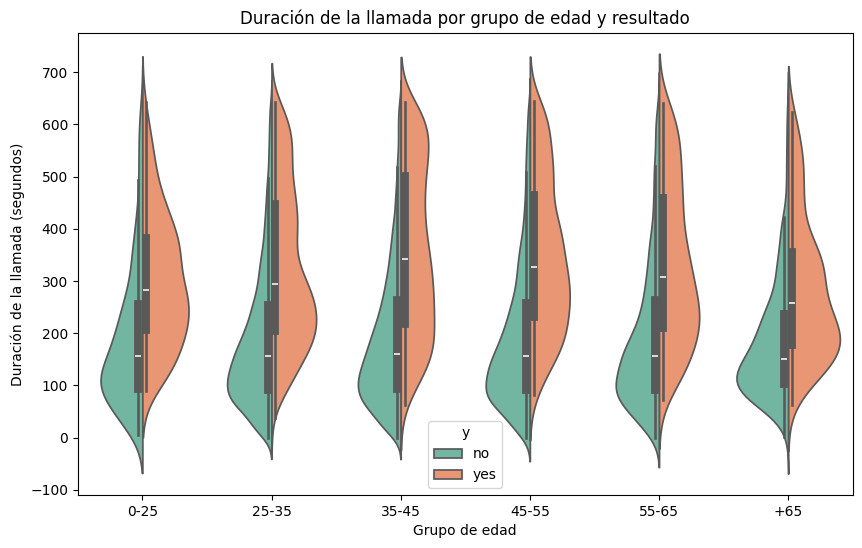

In [99]:
plt.figure(figsize=(10,6))
sns.violinplot(x='intervalo_edad', y='duration', hue='y', data=df_sin_outliers, split=True, palette='Set2')
plt.title('Duración de la llamada por grupo de edad y resultado')
plt.ylabel('Duración de la llamada (segundos)')
plt.xlabel('Grupo de edad')
plt.show()

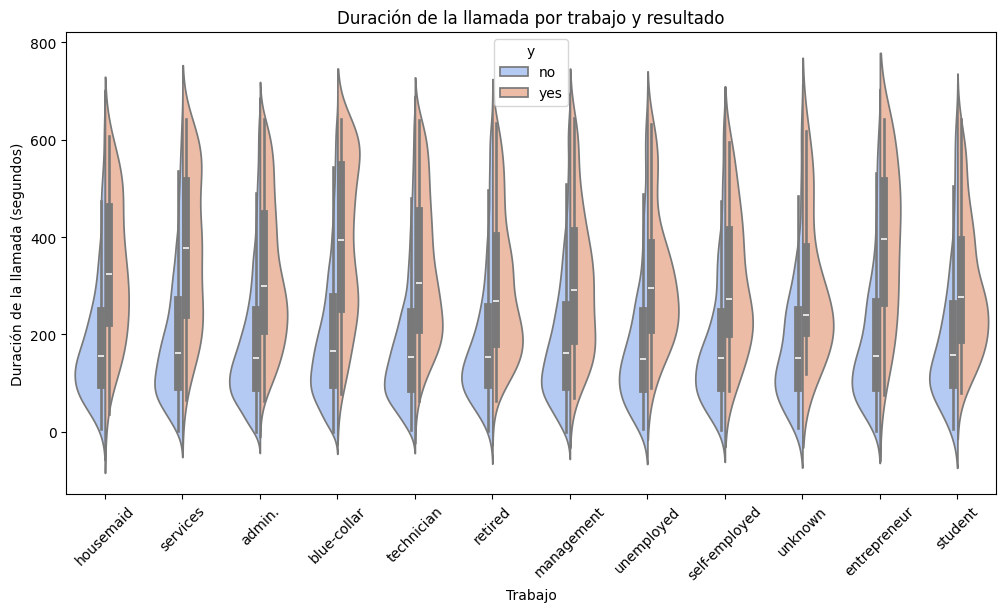

In [100]:
plt.figure(figsize=(12,6))
sns.violinplot(x='job', y='duration', hue='y', data=df_sin_outliers, split=True, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Duración de la llamada por trabajo y resultado')
plt.ylabel('Duración de la llamada (segundos)')
plt.xlabel('Trabajo')
plt.show()

### Cruces finales

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\3551491320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age_job = df_sin_outliers.groupby(['intervalo_edad','job'])['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()


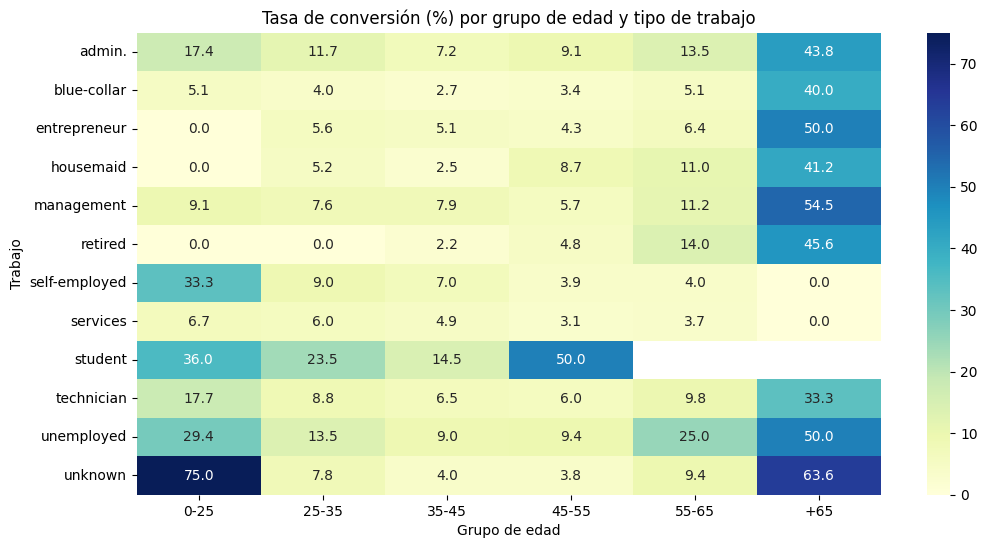

In [101]:
df_age_job = df_sin_outliers.groupby(['intervalo_edad','job'])['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
df_age_job_pivot = df_age_job.pivot(index='job', columns='intervalo_edad', values='y')

plt.figure(figsize=(12,6))
sns.heatmap(df_age_job_pivot, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Tasa de conversión (%) por grupo de edad y tipo de trabajo')
plt.ylabel('Trabajo')
plt.xlabel('Grupo de edad')
plt.show()

[⬆ Volver al índice](#indice)

<a id="kpis"></a>
## KPIs 📈

## Estrategia Data-Driven

**Nombre del Proyecto TFM:** FINTECH  
**Dashboard Persona elegido:** Director de Marketing  
**Acción de negocio buscada:** Aumentar la tasa de contratación de nuestro depósito.  

**Integrantes del Grupo:**  
Diego González de la Rubia  
María Egea Miró  
Leonardo Betancourt  
David Lombardini  
Miguel Retegui  

---

### Links de visualización

- **Link al Dashboard:**  
https://lookerstudio.google.com/reporting/0c8b2c8b-ad93-41e0-90a5-37bf5010afa8/page/tEnnC

- **Link al vídeo:**  
https://drive.google.com/file/d/11m6xSXWhVoTcPBEO1EvOCuizA2d4U5UQ/view?usp=drive_link

---

# Definición Estratégica

## Contexto de Negocio

Análisis de los datos de campañas de marketing de una empresa Fintech con el objetivo de identificar patrones, tendencias y factores que influyen en que un cliente acabe contratando un depósito.

Tras un análisis exhaustivo de los datos disponibles, se plantea implementar un modelo sencillo que permita entender y predecir la efectividad de las campañas de marketing, así como diseñar un dashboard dirigido a la capa ejecutiva de la fintech que muestre los principales insights y KPIs relacionados con el rendimiento de las campañas.

**Industria / Sector:** Fintech  

**Problema de Negocio:**  
Existe un problema de eficiencia en las campañas de marketing realizadas.

**Propuesta de Valor:**  
Aumentar la contratación de depósitos en un **2% en un periodo de 2 años**.

---

# North Star Metric (NSM)

La **North Star Metric** es la métrica única que mejor captura el valor entregado al cliente y al negocio.

### Métrica

**Tasa de conversión de la campaña**, medida a partir del número de clientes que finalmente contratan el depósito.

### Razonamiento

Esta métrica es la más relevante porque refleja directamente el valor generado tanto para el cliente como para el negocio.

### Características de la NSM

- **¿Refleja el valor entregado al cliente?**  
  Sí, ya que los clientes están suficientemente satisfechos como para contratar el depósito y confiar su dinero a la entidad.

- **¿Predice el éxito del negocio?**  
  Sí, porque esta variable explica directamente el éxito de la campaña y, por tanto, el rendimiento del negocio.

- **¿Es fácil de entender?**  
  Sí, se trata de una métrica clara y directa.

- **¿Es medible y rastreable?**  
  Sí, puede registrarse fácilmente en cada campaña y monitorizarse en el tiempo mediante el conteo de conversiones.

---

# Objetivos Generales

**Objetivo:**  
Aumentar la tasa de conversión en la contratación de depósitos en un **2% durante los próximos dos años**.

**Justificación:**  
La empresa obtiene ingresos adicionales a través de la contratación de estos depósitos por parte de sus clientes, lo que aporta valor al negocio y mejora la eficiencia de las campañas de marketing.

---

# Árbol de Indicadores

**North Star Metric:**  
Tasa de conversión de la campaña de contratación de depósitos

OBJETIVO 1
Aumentar la tasa de contratación de nuestro depósito en un 2% en los próximos dos años

└── Estrategia 1.1  
Redistribuir el volumen de llamadas hacia los segmentos de empleo con mayor probabilidad de contratación

    ├── Táctica 1.1.1  
    Reducción del 10% del volumen de llamadas en segmentos con baja tasa de conversión
    
    │   ├── KPI 1: Tasa de conversión por segmento de empleo  
    │   └── KPI 2: % de volumen de llamadas asignadas a segmentos de baja conversión
    
    └── Táctica 1.1.2  
    Incremento del volumen de llamadas en segmentos con alta tasa de conversión
    (estudiantes, jubilados y desempleados)
    
        ├── KPI 3: Tasa de conversión por segmento de empleo  
        └── KPI 4: Tasa de conversión global de la campaña

# Detalle de Estrategias y Tácticas

## Objetivo 1
Aumentar la tasa de contratación de nuestro depósito en un **2% en los próximos dos años**.

### Estrategia 1.1  
Redistribuir el volumen de llamadas hacia los segmentos de empleo con mayor probabilidad de contratación.

**Descripción**

El principal hallazgo del análisis es que la **segmentación impacta directamente en la eficiencia comercial**. No todos los perfiles de clientes presentan la misma probabilidad de conversión, por lo que asignar el esfuerzo comercial de forma homogénea reduce la eficiencia de las campañas.

Los datos muestran que existen segmentos con mayor propensión a contratar el depósito — especialmente **jubilados, estudiantes y personas desempleadas** — lo que confirma que la variable **empleo** tiene capacidad predictiva sobre la conversión.

---

### Táctica 1.1.1  
Reducción del 10% del volumen de llamadas en segmentos de empleo con baja tasa de conversión.

**Descripción**

Partiendo de una base aproximada de **37.500 llamadas**, y excluyendo los segmentos con mayor conversión (jubilados, estudiantes y desempleados), se propone reducir un **10% del volumen de llamadas** en los segmentos con menor tasa de conversión.

Esto supone aproximadamente **3.758 llamadas**, que serán redistribuidas de forma equitativa entre los segmentos con mayor probabilidad de conversión.

### KPIs asociados

- **KPI 1:** Tasa de conversión por cada segmento de empleo  
- **KPI 2:** Porcentaje de volumen de llamadas asignadas a segmentos de baja conversión


[⬆ Volver al índice](#indice)

<a id="conclusiones"></a>
## Conclusiones 📝

En esta sección se resumen los principales hallazgos del análisis de las campañas de marketing del banco.

[⬆ Volver al índice](#indice)